In [ ]:
import pandas as pd

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(
    "C:\\Users\\liuda\\Desktop\\master\\SBD\\privelet_project\\data\\adult.data",
    header=None,
    names=columns,
    skipinitialspace=True,
    na_values="?"
)

print(df.head())
print(df.shape)
print(df["education"].head())
print(df.iloc[0])

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [3]:
education_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]

hist = df["education"].value_counts()
hist = hist.reindex(education_order, fill_value=0)

print(hist)

education
Preschool          51
1st-4th           168
5th-6th           333
7th-8th           646
9th               514
10th              933
11th             1175
12th              433
HS-grad         10501
Some-college     7291
Assoc-voc        1382
Assoc-acdm       1067
Bachelors        5355
Masters          1723
Prof-school       576
Doctorate         413
Name: count, dtype: int64


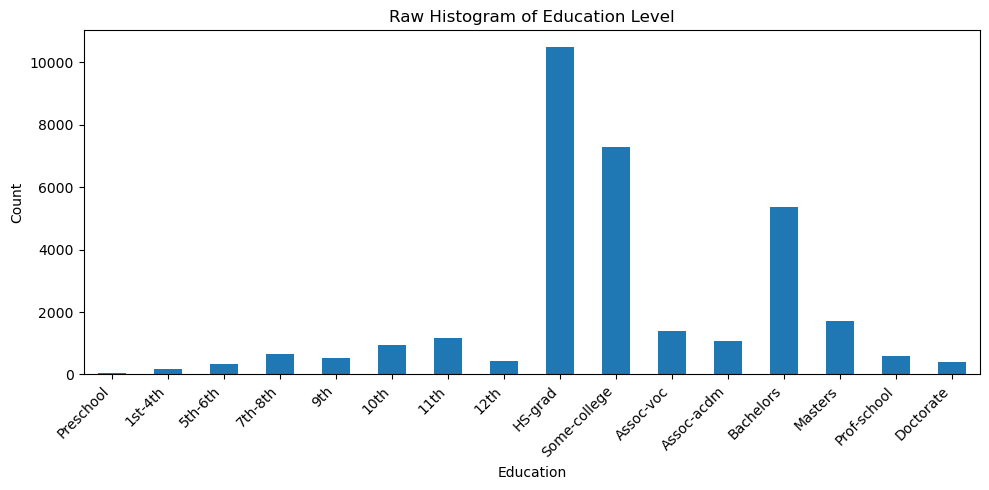

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
hist.plot(kind="bar")
plt.title("Raw Histogram of Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("C:\\Users\\liuda\\Desktop\\master\\SBD\\privelet_project\\results\\raw_education_histogram.png")
plt.show()

Q1

We use 3 functions:

wavelet_transform converts the raw histogram into Haar wavelet coefficients.

add_laplace_noise perturbs these coefficients with Laplace noise according to epsilon.

inverse_wavelet_transform reconstructs the noisy histogram from the noisy coefficients.

In [5]:
import numpy as np
def wavelet_transform(hist):
    """
    Convert the histogram into Haar wavelet
    
    Parameters:
        hist: array
            Input histogram. Its length must be a power of 2.

    Returns:
        dict
            A dictionary with:
            - "base": the global average value
            - "details": a list of detail coefficient arrays
            stored from lower level to higher level
    """
    x=np.array(hist,dtype=float)
    n=len(x)
    
    # Haar transform requires length = 2^l
    if n==0 or (n & (n - 1)) != 0:
        raise ValueError("Input length must be a power of 2")
    
    details=[]
    current=x
    
    # At each level, group values in pairs and compute
    # their averages and differences
    while len(current) > 1:
        avg=(current[0::2]+current[1::2])/2
        diff=(current[0::2]-current[1::2])/2
        details.append(diff)
        current=avg
        
    # The last remaining value is the global average
    base = current[0]
    return {"base": base, "details": details}


In [7]:
def add_laplace_noise(coeffs, epsilon, random_state=None):
    """
    Add Laplace noise to Haar wavelet coefficients.

    Parameters:
        coeffs: dict
            Dictionary with:
            - "base": base coefficient
            - "details": list of detail coefficient arrays
        epsilon: float
            Privacy budget
        random_state: int or None
            Random seed

    Returns:
        dict
            Noisy wavelet coefficients with the same structure as the input.
    """
    rng = np.random.default_rng(random_state)

    # Number of detail levels
    l = len(coeffs["details"]) 
    
    # Original histogram length, length = 2^l
    m = 2 ** l                 
    
    # Noise scale parameter
    lam = 2 * (1 + np.log2(m)) / epsilon
    
    noisy = {
        "base": None,
        "details": []
    }

    # Add noise to the base coefficient
    noisy["base"] = coeffs["base"] + rng.laplace(0, lam / m)
    
    # Add noise to each level of detail coefficients
    for i, arr in enumerate(coeffs["details"], start=1):
        weight = 2 ** (l - i + 1)
        noisy_arr = arr + rng.laplace(0, lam / weight, size=arr.shape)
        noisy["details"].append(noisy_arr)

    return noisy

In [8]:
def inverse_wavelet_transform(coeffs):
    """
    Reconstruct a histogram from 1D Haar wavelet coefficients.

    Parameters:
        coeffs: dict
            Dictionary with:
            - "base": the global average value
            - "details": list of detail coefficient arrays,
            stored from lower level to higher level
    Returns:
        numpy.ndarray
            Reconstructed histogram.
    """
    base = coeffs["base"]
    details = coeffs["details"]
    
    # Start from the top-level average
    current = np.array([base])
    
    # Reconstruct from higher level to lower level
    for diff in reversed(details):
        avg = current
        current = np.empty(len(avg) * 2)
        current[0::2] = avg + diff
        current[1::2] = avg - diff
    return current 

In [9]:
def privelet_1d(hist, epsilon, random_state=None):
    """
    Apply the full 1D Privelet algorithm to a histogram.

    Parameters:
        hist: array
            Input histogram
        epsilon: float
            Privacy budget
        random_state: int or None
            Random seed for reproducibility

    Returns:
        numpy.ndarray
            Noisy histogram after Privelet perturbation.
    """
    coeffs = wavelet_transform(hist)
    noisy_coeffs = add_laplace_noise(coeffs, epsilon, random_state=random_state)
    noisy_hist = inverse_wavelet_transform(noisy_coeffs)
    return noisy_hist

Q2 Test your code with Privelet to compute query H1 with ∈{0.01,0.1,1} 

In [10]:
hist_array = hist.values.astype(float)
print(hist_array)

[   51.   168.   333.   646.   514.   933.  1175.   433. 10501.  7291.
  1382.  1067.  5355.  1723.   576.   413.]


In [11]:
epsilons = [0.01, 0.1, 1.0]

results = {}

for eps in epsilons:
    noisy_hist = privelet_1d(hist_array, epsilon=eps, random_state=42)
    results[eps] = noisy_hist

    print(f"\nEpsilon = {eps}")
    print(noisy_hist)


Epsilon = 0.01
[  -55.61997618    77.6782271    339.59247597   494.71739667
   -95.95235488   260.28631406   504.065352     -29.25609625
 11343.8206202   7756.20294062  1601.94873385  1194.60757828
  5924.41746698  2186.30088941   922.42888284   929.64019197]

Epsilon = 0.1
[   40.33800238   158.96782271   333.6592476    630.87173967
   453.00476451   865.72863141  1107.9065352    386.77439038
 10585.28206202  7337.52029406  1403.99487338  1079.76075783
  5411.9417467   1769.33008894   610.64288828   464.6640192 ]

Epsilon = 1.0
[   49.93380024   167.09678227   333.06592476   644.48717397
   507.90047645   926.27286314  1168.29065352   428.37743904
 10509.4282062   7295.65202941  1384.19948734  1068.27607578
  5360.69417467  1727.63300889   579.46428883   418.16640192]


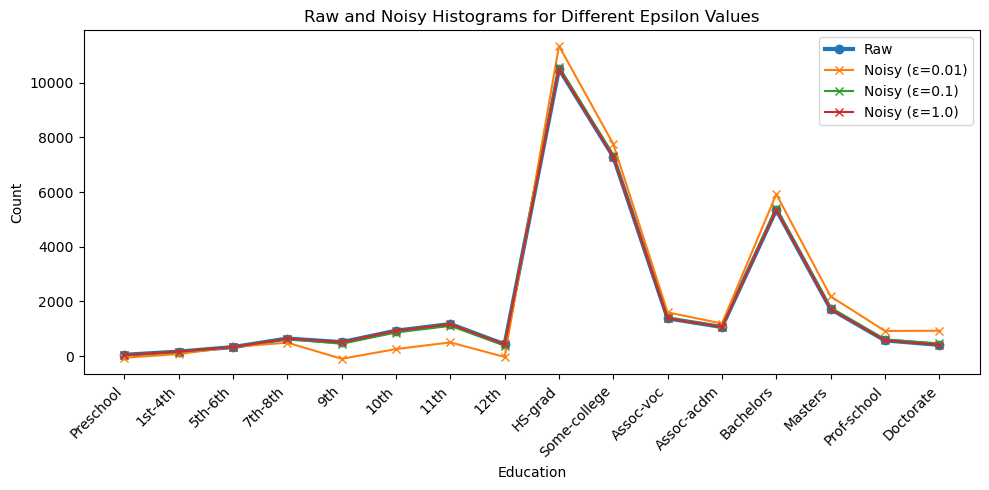

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(hist_array, marker='o', linewidth=3, label='Raw')

for eps in epsilons:
    plt.plot(results[eps], marker='x', linewidth=1.5, label=f'Noisy (ε={eps})')

plt.xticks(range(len(education_order)), education_order, rotation=45, ha='right')
plt.title("Raw and Noisy Histograms for Different Epsilon Values")
plt.xlabel("Education")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Q3 

In [13]:
from scipy.stats import wasserstein_distance

In [14]:
def compute_distance(hist_array, epsilon):
    noisy = privelet_1d(hist_array, epsilon=epsilon)
    dist = wasserstein_distance(hist_array, noisy)
    return dist

In [15]:
epsilons = [0.01, 0.1, 1.0, 10.0]

results = {}

for eps in epsilons:
    distances = []

    for _ in range(20):
        d = compute_distance(hist_array, eps)
        distances.append(d)

    results[eps] = distances

In [16]:
summary = {}

for eps in epsilons:
    arr = np.array(results[eps])
    summary[eps] = {
        "avg": arr.mean(),
        "min": arr.min(),
        "max": arr.max()
    }

    print(f"\nEpsilon = {eps}")
    print(summary[eps])


Epsilon = 0.01
{'avg': 516.537168079939, 'min': 114.55469325501075, 'max': 3728.6034512512615}

Epsilon = 0.1
{'avg': 56.180669304885065, 'min': 16.932132955829726, 'max': 181.14336843082987}

Epsilon = 1.0
{'avg': 5.648549529341172, 'min': 2.1022500697851925, 'max': 11.938847337110438}

Epsilon = 10.0
{'avg': 0.7684031100271764, 'min': 0.15365809674182795, 'max': 3.4830767761965507}


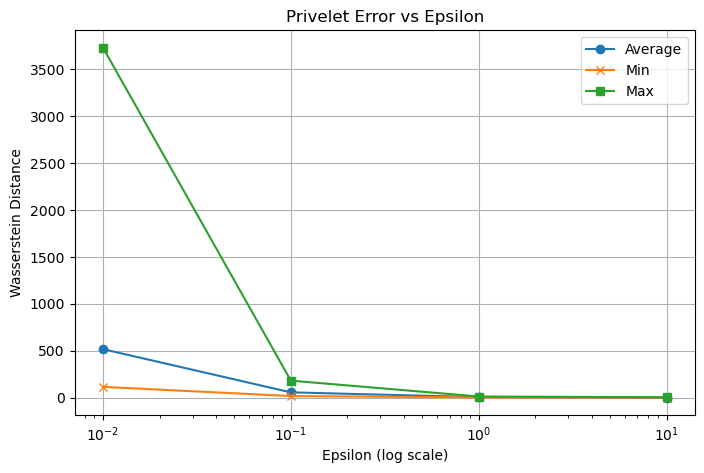

In [17]:
avg_vals = [summary[eps]["avg"] for eps in epsilons]
min_vals = [summary[eps]["min"] for eps in epsilons]
max_vals = [summary[eps]["max"] for eps in epsilons]

plt.figure(figsize=(8, 5))

plt.plot(epsilons, avg_vals, marker='o', label='Average')
plt.plot(epsilons, min_vals, marker='x', label='Min')
plt.plot(epsilons, max_vals, marker='s', label='Max')

plt.xscale('log')  #
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Wasserstein Distance")
plt.title("Privelet Error vs Epsilon")

plt.legend()
plt.grid()
plt.show()

For whole dataset, when ε increases, the Wasserstein distance decreases.

For individual data, a smaller ε adds more noise, which better hides the contribution of each individual record and provides stronger privacy protection.

Therefore, small ε improves privacy at the cost of lower utility, while large ε improves utility but weakens privacy.

go further: 
1. from 10^-2 ~ 10^-1, it is sharp. Is it always sharp? Can we find some points between that?
2. does it perform same on other dateset?


In [25]:
extra_results = {}
extra_epsilons = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.5, 1, 10]

for eps in extra_epsilons:
    distances = []
    for _ in range(20):
        noisy = privelet_1d(hist_array, epsilon=eps)
        d = wasserstein_distance(hist_array, noisy)
        distances.append(d)
    extra_results[eps] = distances

extra_summary = {}
for eps in extra_epsilons:
    arr = np.array(extra_results[eps])
    extra_summary[eps] = {
        "avg": arr.mean(),
        "min": arr.min(),
        "max": arr.max()
    }

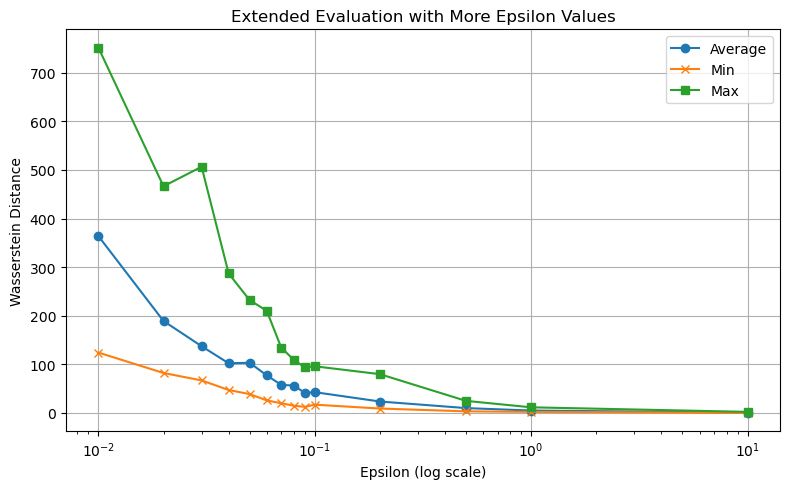

In [26]:
avg_vals = [extra_summary[eps]["avg"] for eps in extra_epsilons]
min_vals = [extra_summary[eps]["min"] for eps in extra_epsilons]
max_vals = [extra_summary[eps]["max"] for eps in extra_epsilons]

plt.figure(figsize=(8, 5))
plt.plot(extra_epsilons, avg_vals, marker='o', label='Average')
plt.plot(extra_epsilons, min_vals, marker='x', label='Min')
plt.plot(extra_epsilons, max_vals, marker='s', label='Max')

plt.xscale('log')
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Wasserstein Distance")
plt.title("Extended Evaluation with More Epsilon Values")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The extended experiment shows that the drop between 0.01 and 0.1 is sharp. By adding more epsilon values, we can see that the distance decreases a lot in the very small epsilon range, especially before 0.05. After that, the curve becomes more stable.

Still, the curve is not perfectly smooth. This is normal because Privelet is random, and the maximum value can be affected by a few noisy runs. The average trend is more important, and it clearly decreases when epsilon increases.


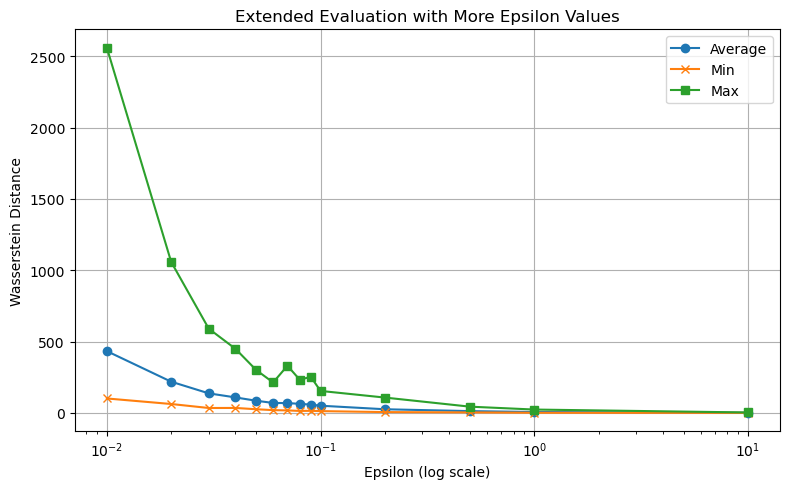

In [37]:
extra_results = {}
extra_epsilons = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.5, 1, 10]

for eps in extra_epsilons:
    distances = []
    for _ in range(100):
        noisy = privelet_1d(hist_array, epsilon=eps)
        d = wasserstein_distance(hist_array, noisy)
        distances.append(d)
    extra_results[eps] = distances

extra_summary = {}
for eps in extra_epsilons:
    arr = np.array(extra_results[eps])
    extra_summary[eps] = {
        "avg": arr.mean(),
        "min": arr.min(),
        "max": arr.max()
    }
avg_vals = [extra_summary[eps]["avg"] for eps in extra_epsilons]
min_vals = [extra_summary[eps]["min"] for eps in extra_epsilons]
max_vals = [extra_summary[eps]["max"] for eps in extra_epsilons]

plt.figure(figsize=(8, 5))
plt.plot(extra_epsilons, avg_vals, marker='o', label='Average')
plt.plot(extra_epsilons, min_vals, marker='x', label='Min')
plt.plot(extra_epsilons, max_vals, marker='s', label='Max')

plt.xscale('log')
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Wasserstein Distance")
plt.title("Extended Evaluation with More Epsilon Values")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

I also tested 100 runs, and the average curve became smoother and more stable.

Compare to 20 runs, when the number of runs increases, the average curve becomes smoother because the result is based on more repeated random trials. Each run uses random Laplace noise, so a small number of runs may produce a more unstable average. With more runs, the estimated mean becomes more stable.

However, the minimum and maximum values do not always become smoother, because extreme values are more likely to appear when the number of runs increases.